# Futures/Spot HBT Step-by-Step Runner

The notebook is intentionally thin. Configuration, pipeline stages, report tables, and plotting live in separate Python scripts in this folder. Both this notebook and `run_full_backtest.py` save CSV reports and PNG figures.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots

## 1. Parameters

In [2]:
args = default_notebook_args(
    start_date='2026-05-01',
    end_date='2026-05-31',
    order_latency_ms=10.0,
    response_latency_ms=10.0,
    feed_latency_offset_ms=10.0,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=True,
)
args.output_dir

PosixPath('/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260501_20260531_latency_10ms')

## 2. Full Backtest and Core CSV Outputs

In [ ]:
artifacts = run_backtest_pipeline(args)
display(artifacts.frame('summary').head(20))
display(artifacts.frame('entry_exit_index').head(20))

## 3. Analysis CSV Outputs

In [ ]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('roi_summary_including_open'))
print(f'Report CSV directory: {reports.output_dir}')

ArrowInvalid: ('Integer value 1777857193502000000 is outside of the range exactly representable by a IEEE 754 double precision value', 'Conversion failed for column flatten_local_timestamp with type object')

## 4. Saved PNG Outputs

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/performance_overview.png


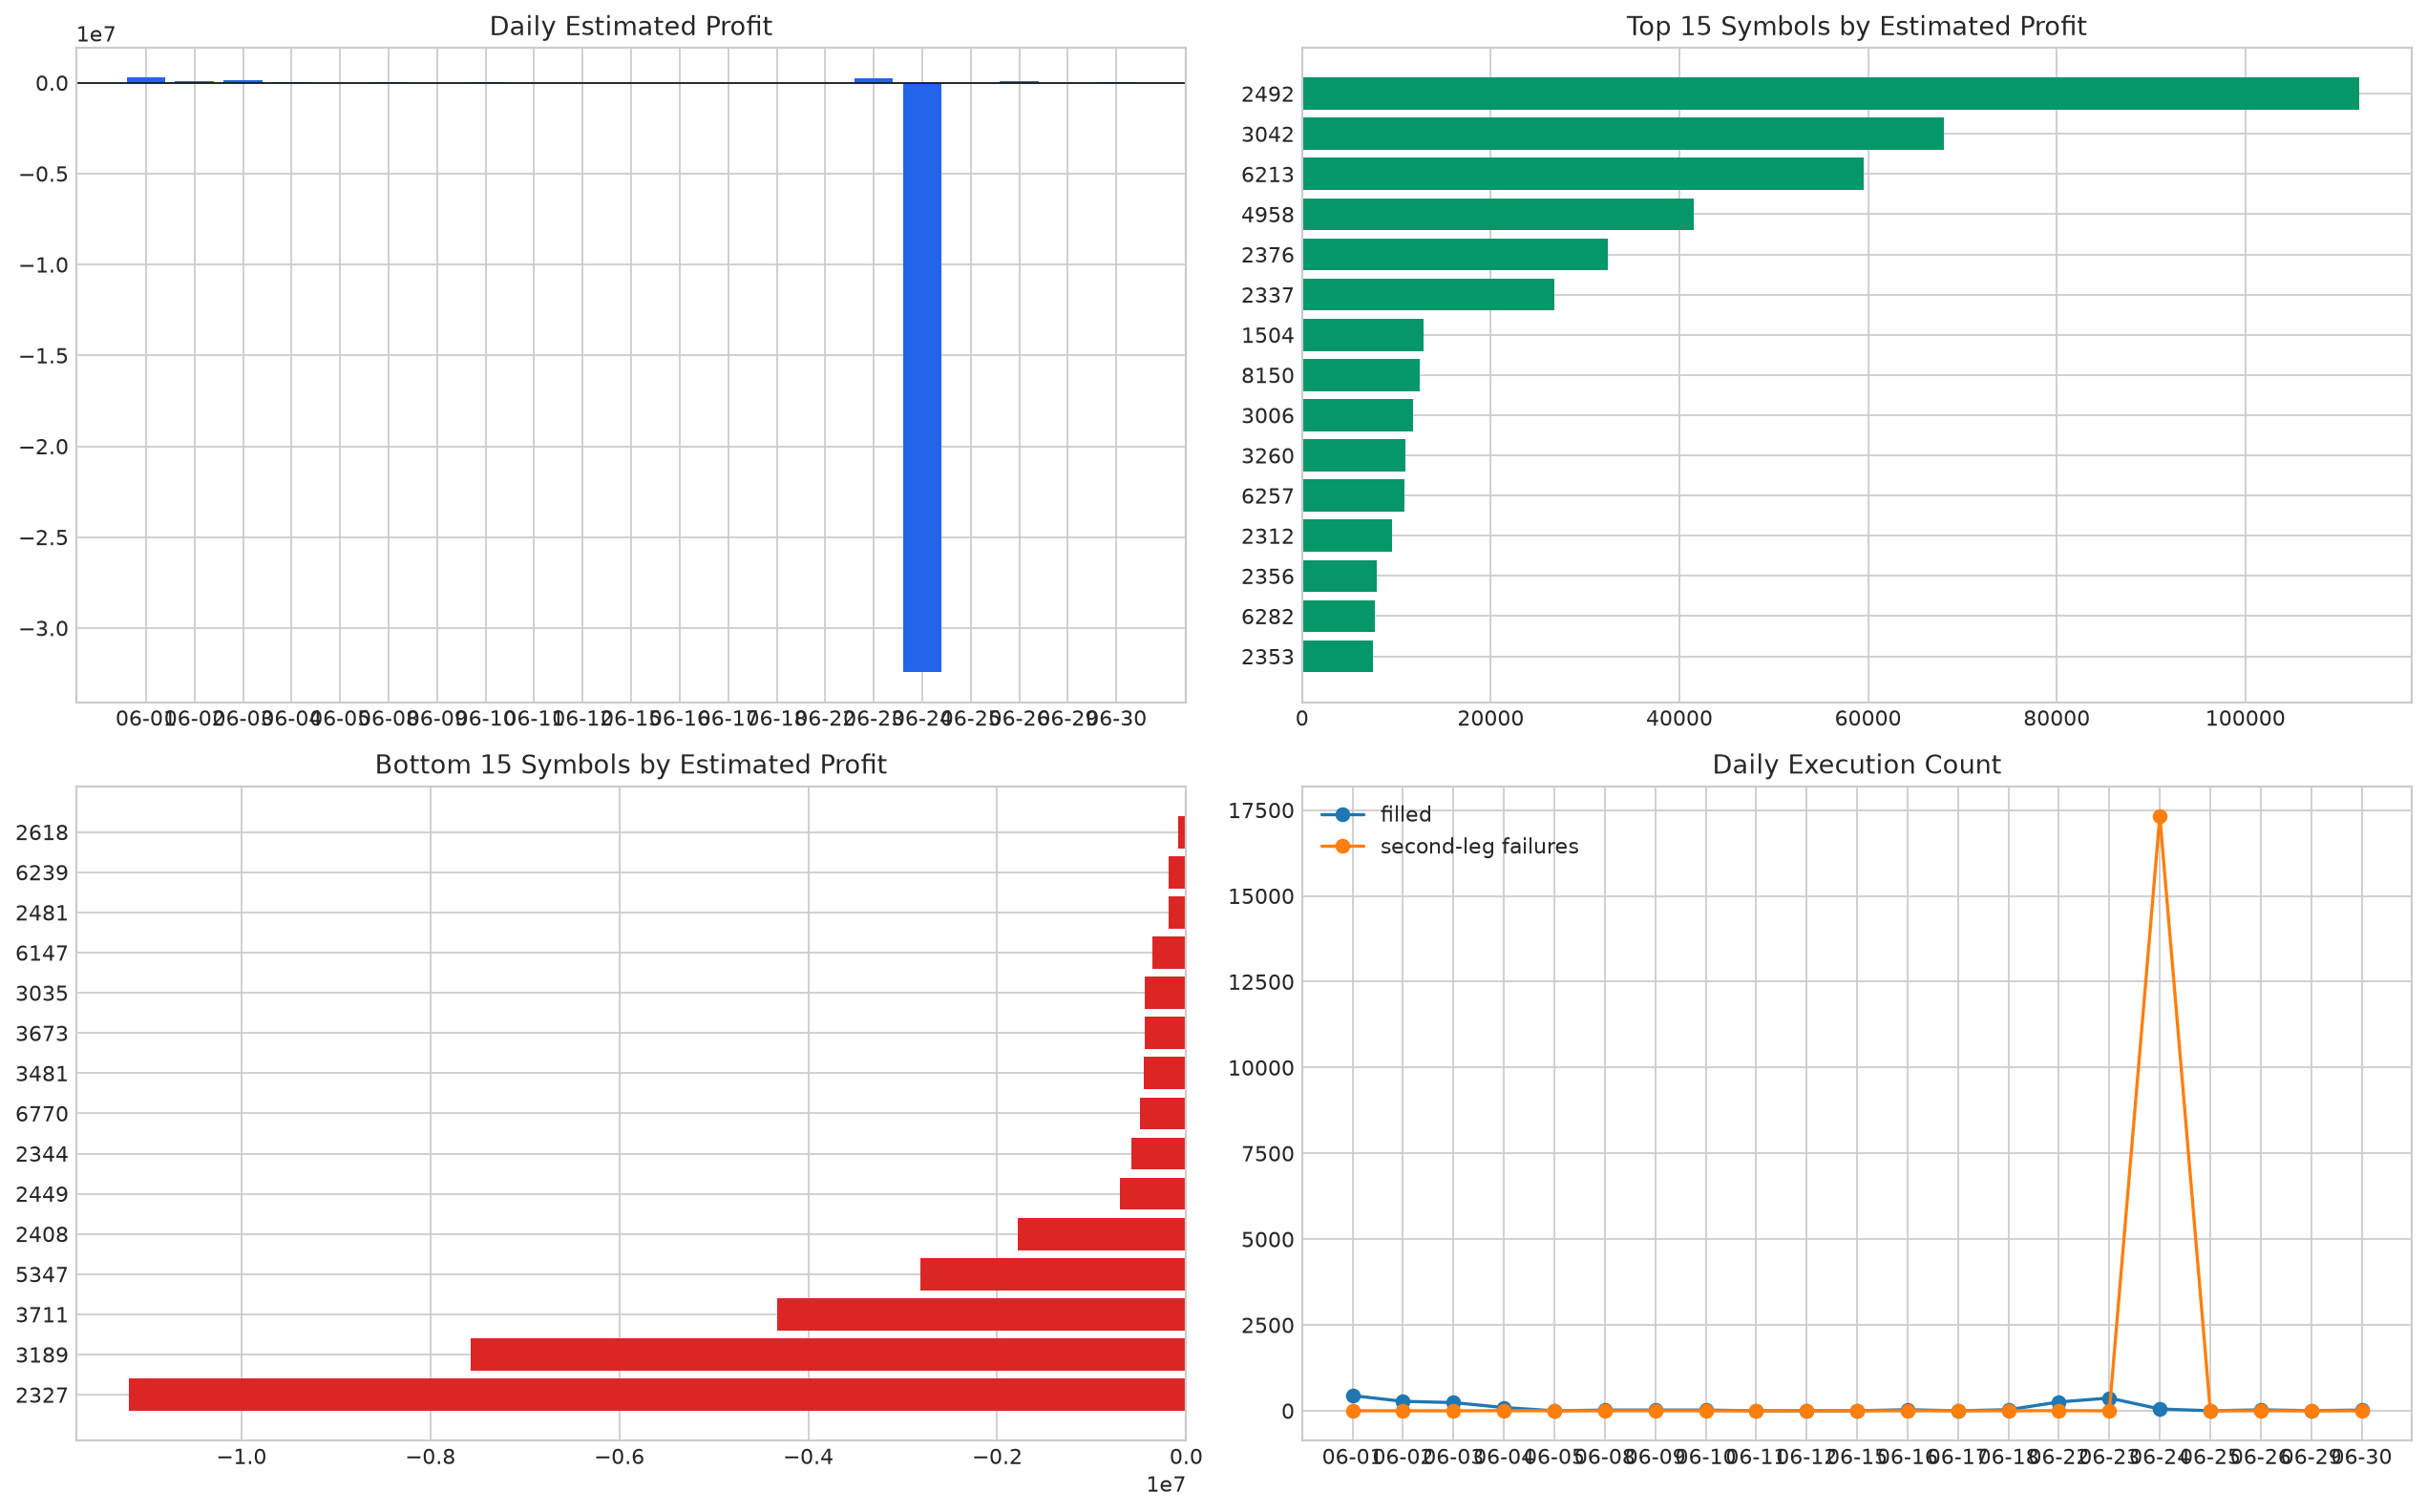

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/pair_profit_scatter.png


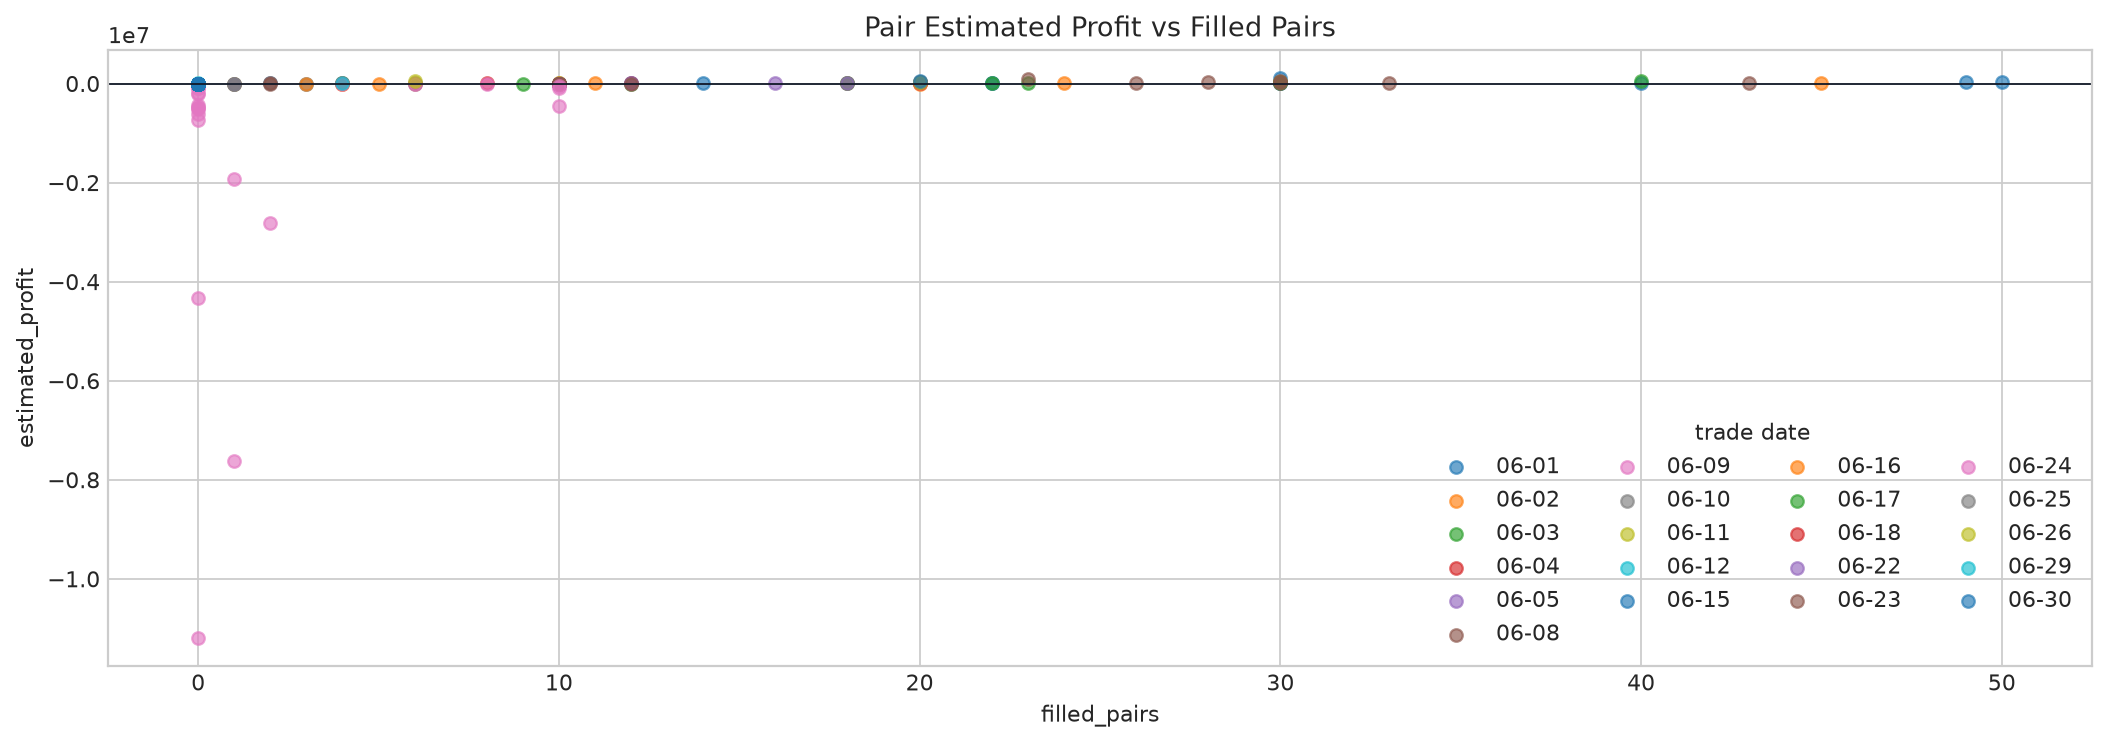

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/stuck_cash.png


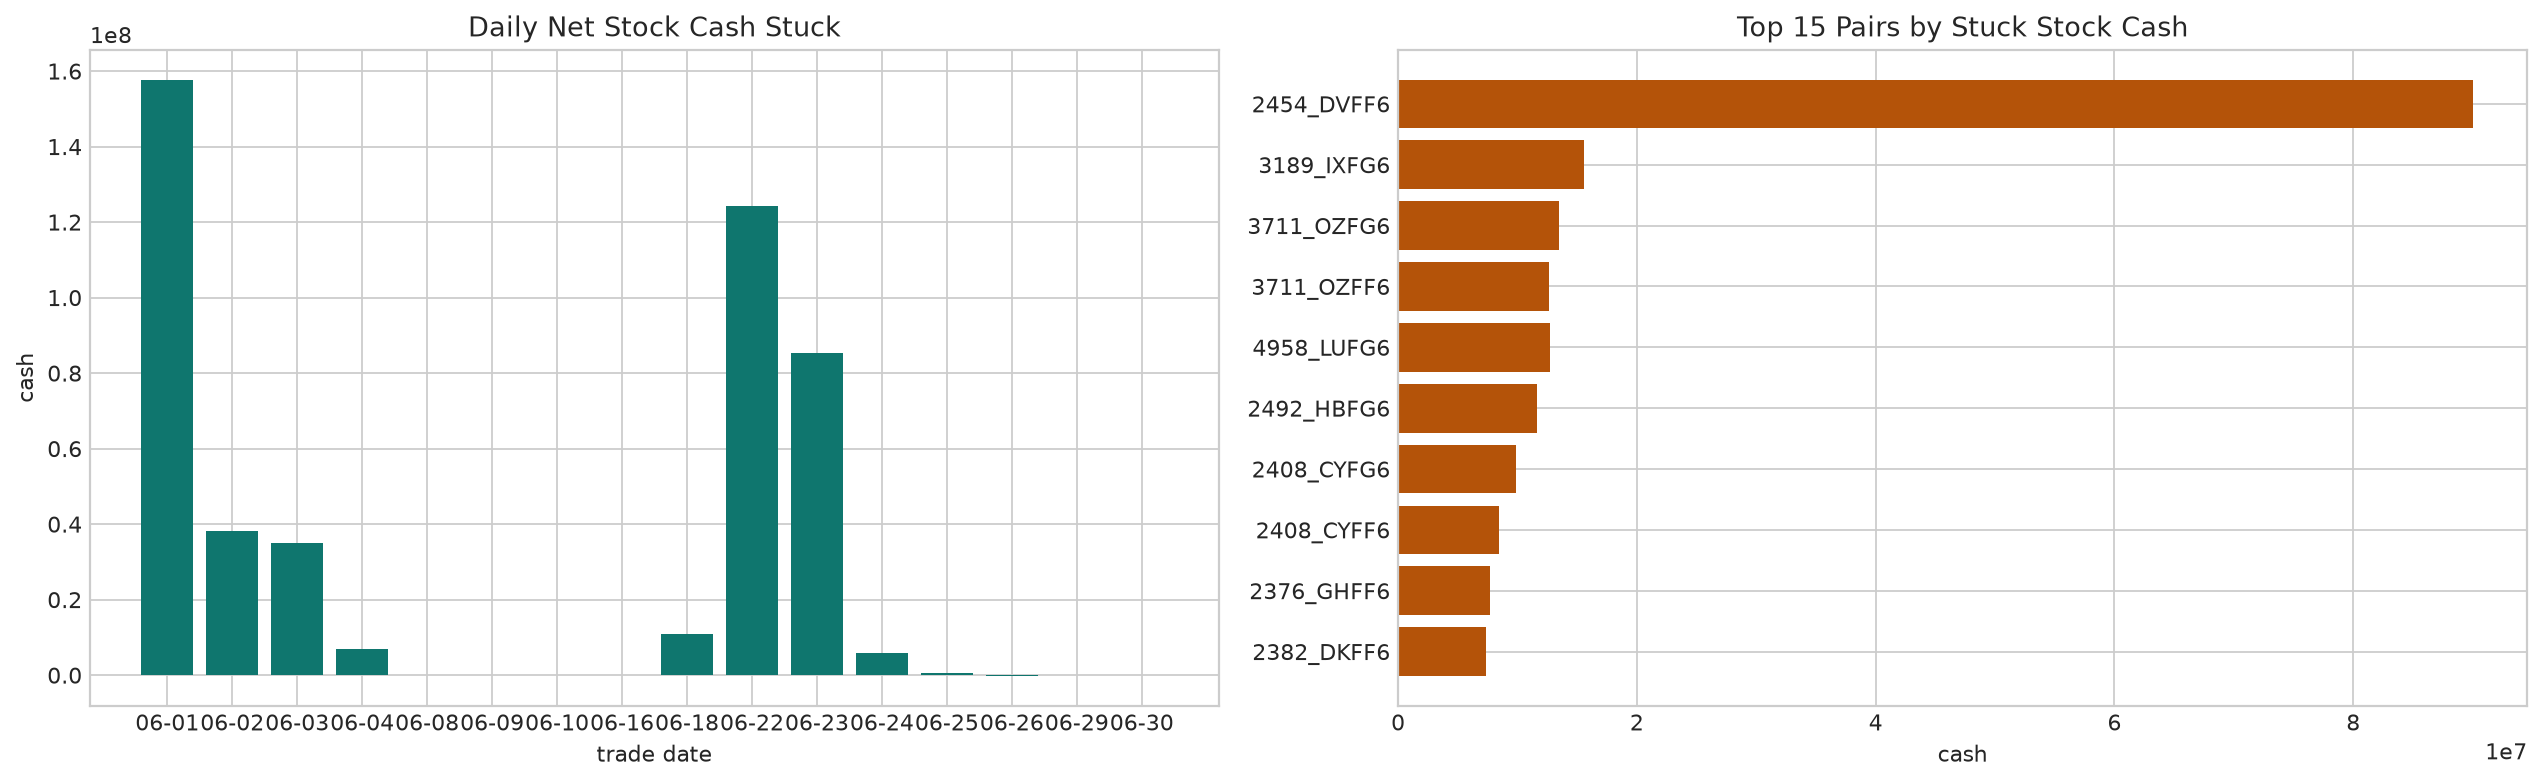

roi_including_open: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/roi_including_open.png


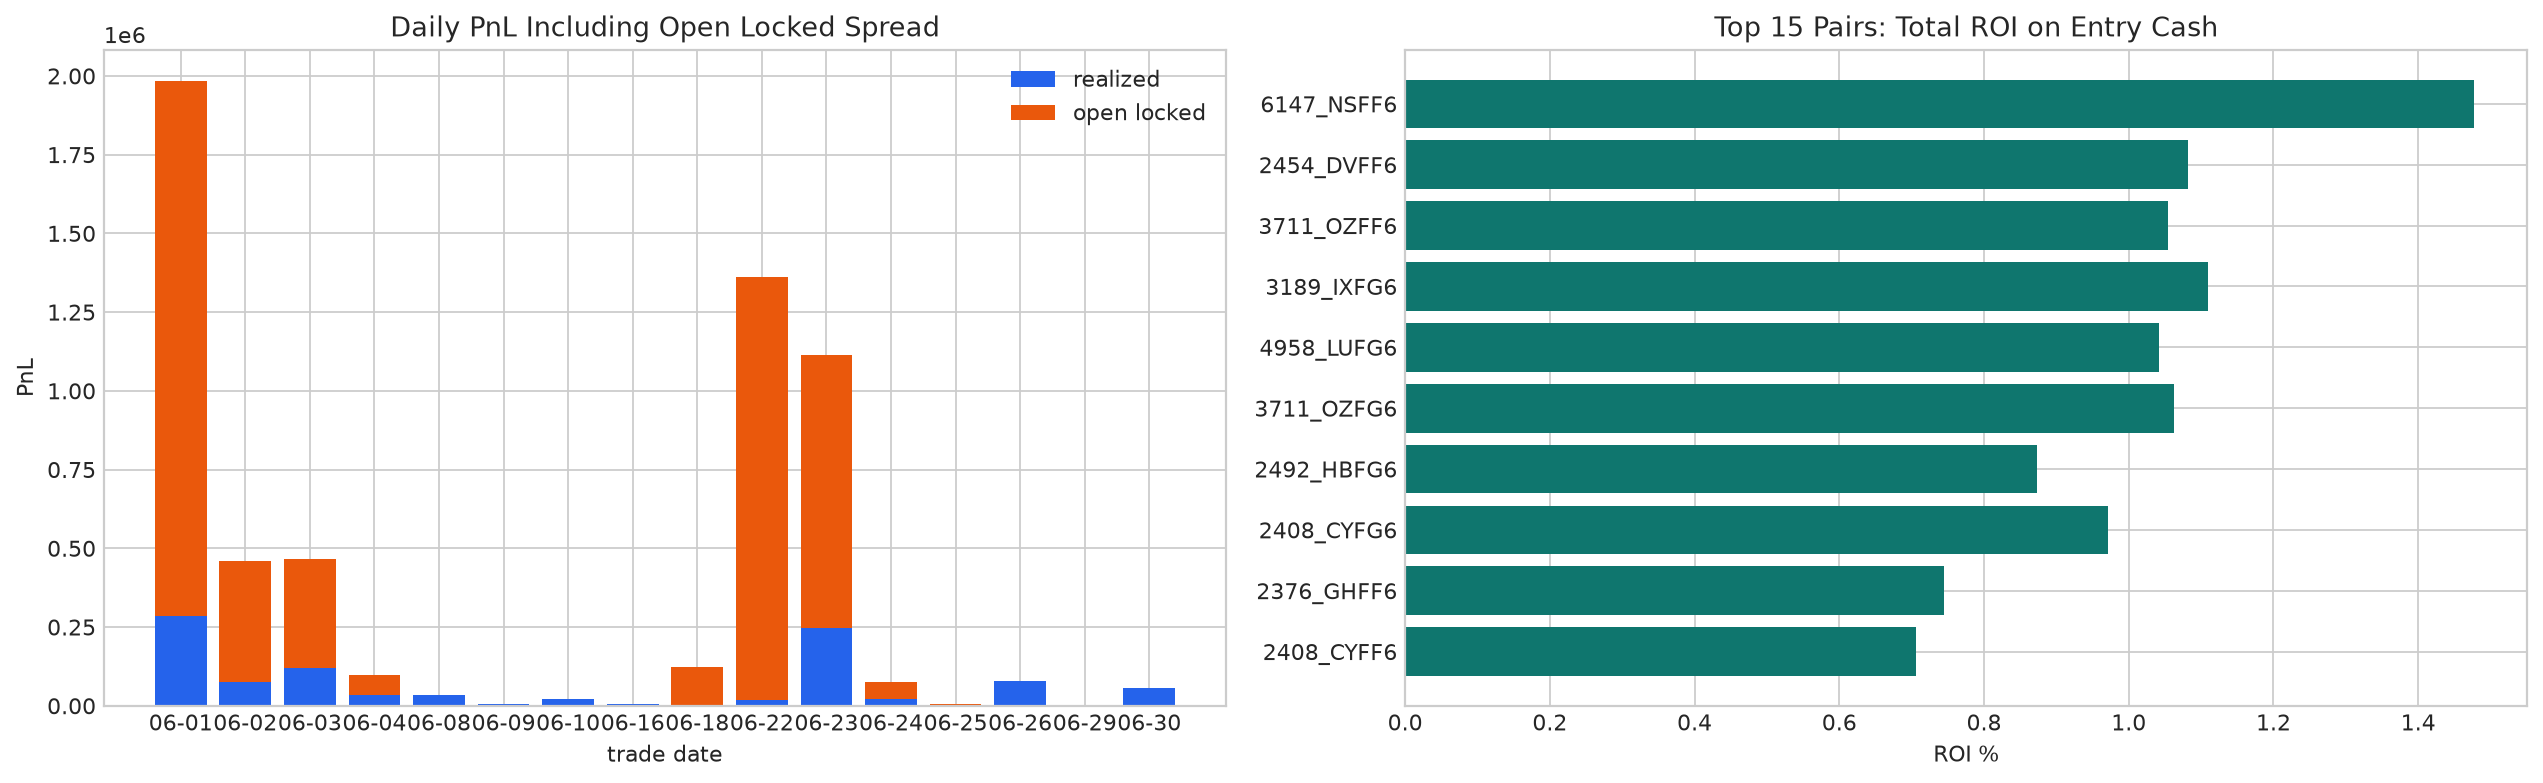

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/figures/latency_timelines.png


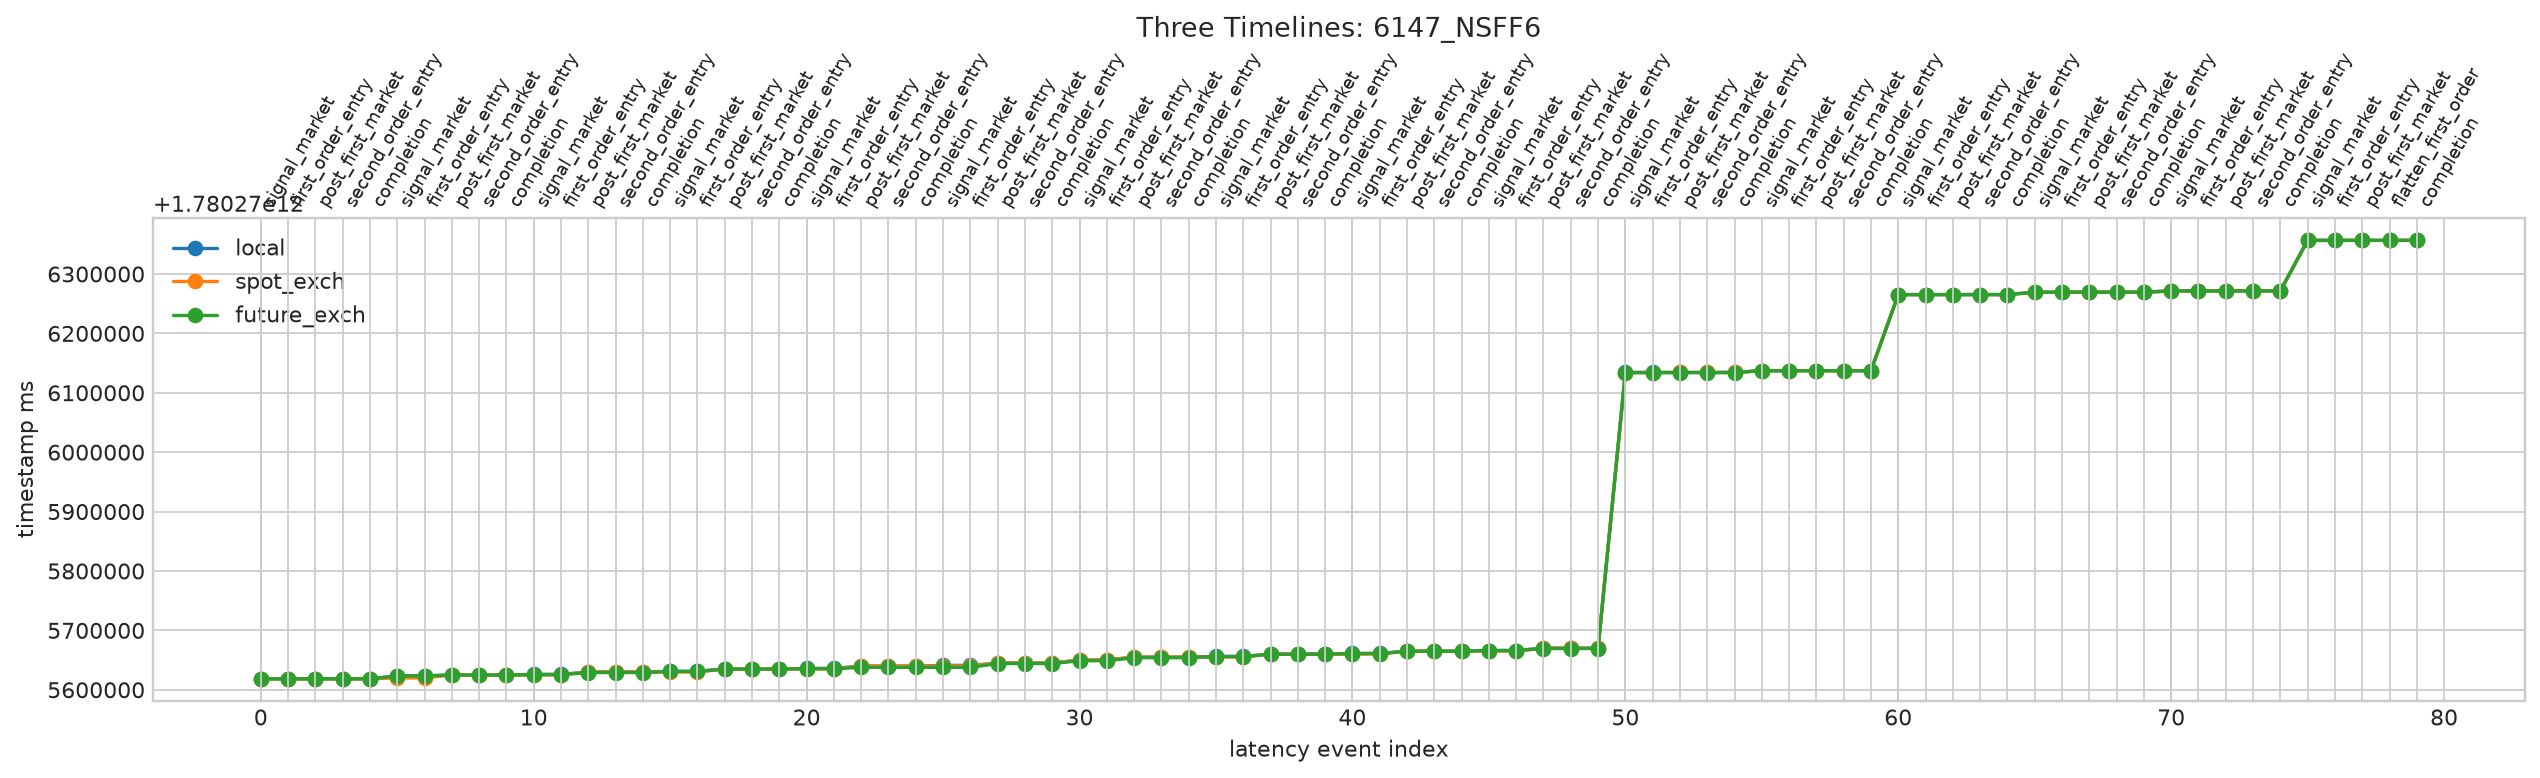

In [ ]:
figure_paths = save_report_plots(artifacts, reports)
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## 5. Optional Drill-down

In [ ]:
selected_pair = reports.selected_pair
entry_exit = artifacts.frame('entry_exit_all')
latency = artifacts.frame('latency')
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    if 'pair_name' in entry_exit.columns:
        display(entry_exit.loc[entry_exit['pair_name'].eq(selected_pair)].head(100))
    if 'pair_name' in latency.columns:
        display(latency.loc[latency['pair_name'].eq(selected_pair)].head(120))

,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
143178,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:00:18.451000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,303.5,304.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143179,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:00:18.530000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,303.5,304.0,NaN,...,sell,308.5,308.5,1.0,stock,buy,305.0,304.0,2.0,59.000064
143180,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:00:23.530000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,303.0,304.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143181,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:00:25.026000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,300.0,300.5,NaN,...,sell,308.5,308.5,1.0,stock,buy,301.5,300.5,2.0,1476.000000
143182,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:00:26.026000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,300.0,300.5,76.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143273,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:01:46.167000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,300.5,301.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143274,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:01:47.167000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,300.5,301.0,47.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143275,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:01:47.167000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,300.5,301.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143276,2026-06-01,2026-06-01::6147_NSFF6,2026-06-01 09:01:48.167000+08:00,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,300.5,301.0,47.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
2016,2026-06-01,2026-06-01::6147_NSFF6,1780275618451000000,18,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1780275618432000000,1780275618442000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-06-01 09:00:18.451000+08:00
2017,2026-06-01,2026-06-01::6147_NSFF6,1780275618471000000,18,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1780275618432000000,1780275618442000000,10000000,1.780276e+18,1.780276e+18,1.780276e+18,10000000.0,10000000.0,2026-06-01 09:00:18.451000+08:00
2018,2026-06-01,2026-06-01::6147_NSFF6,1780275618510000000,18,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1780275618488000000,1780275618498000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-06-01 09:00:18.510000+08:00
2019,2026-06-01,2026-06-01::6147_NSFF6,1780275618530000000,18,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1780275618488000000,1780275618498000000,10000000,1.780276e+18,1.780276e+18,1.780276e+18,10000000.0,10000000.0,2026-06-01 09:00:18.510000+08:00
2020,2026-06-01,2026-06-01::6147_NSFF6,1780275618530000000,18,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,None,...,10000000,1780275618488000000,1780275618498000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-06-01 09:00:18.530000+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2131,2026-06-01,2026-06-01::6147_NSFF6,1780276825165000000,1189,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1780276824620000000,1780276824630000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-06-01 09:20:25.165000+08:00
2132,2026-06-01,2026-06-01::6147_NSFF6,1780276825185000000,1189,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1780276824620000000,1780276824630000000,10000000,1.780277e+18,1.780277e+18,1.780277e+18,10000000.0,10000000.0,2026-06-01 09:20:25.165000+08:00
2133,2026-06-01,2026-06-01::6147_NSFF6,1780276825261000000,1189,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1780276824620000000,1780276824630000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-06-01 09:20:25.261000+08:00
2134,2026-06-01,2026-06-01::6147_NSFF6,1780276825281000000,1189,6147_NSFF6,6147,NSFF6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1780276824620000000,1780276824630000000,10000000,1.780277e+18,1.780277e+18,1.780277e+18,10000000.0,10000000.0,2026-06-01 09:20:25.261000+08:00
